# Part - A : Load and explore 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
ratings = pd.read_csv('data/ratings.csv')
movies = pd.read_csv('data/movies.csv')

In [28]:
print("Ratings Dataset:")
display(ratings.head())
print("\nMovies Dataset:")
display(movies.head())
print("Ratings columns:")
print(ratings.columns.tolist())
print("Movies columns:")
print(movies.columns.tolist())

Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings columns:
['userId', 'movieId', 'rating', 'timestamp']
Movies columns:
['movieId', 'title', 'genres']


### Basic Dataset Statistics

The number of unique users, unique movies, and ratings in the dataset.

In [29]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()   
num_ratings = len(ratings)

print(f"Number of unique users: {num_users}")
print(f"Number of unique movies: {num_movies}")
print(f"Total number of ratings: {num_ratings}")

Number of unique users: 610
Number of unique movies: 9724
Total number of ratings: 100836


### Dataset Sparsity

Sparsity is the fraction of possible user-movie pairs for which no rating is available.

In [30]:
total_possible_ratings = num_users * num_movies
num_missing_ratings = total_possible_ratings - num_ratings
sparsity = (num_missing_ratings / total_possible_ratings) * 100
print(f"Total possible ratings: {total_possible_ratings}")
print(f"Number of missing ratings: {num_missing_ratings}")
print(f"Sparsity: {sparsity:.2f}%")

Total possible ratings: 5931640
Number of missing ratings: 5830804
Sparsity: 98.30%


### User-Item Rating Matrix

We represent the ratings as a matrix where rows correspond to users, columns correspond to movies, and each cell contains the user's rating for that movie. Missing ratings are represented by NaN.

In [31]:
user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating')
print(f"User-Item Matrix: {user_item_matrix.shape}")
display(user_item_matrix.head())

User-Item Matrix: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Rating Distribution

We examine how each rating value occurs in the dataset.

In [32]:
rating_counts = ratings['rating'].value_counts().sort_index()
display(rating_counts)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

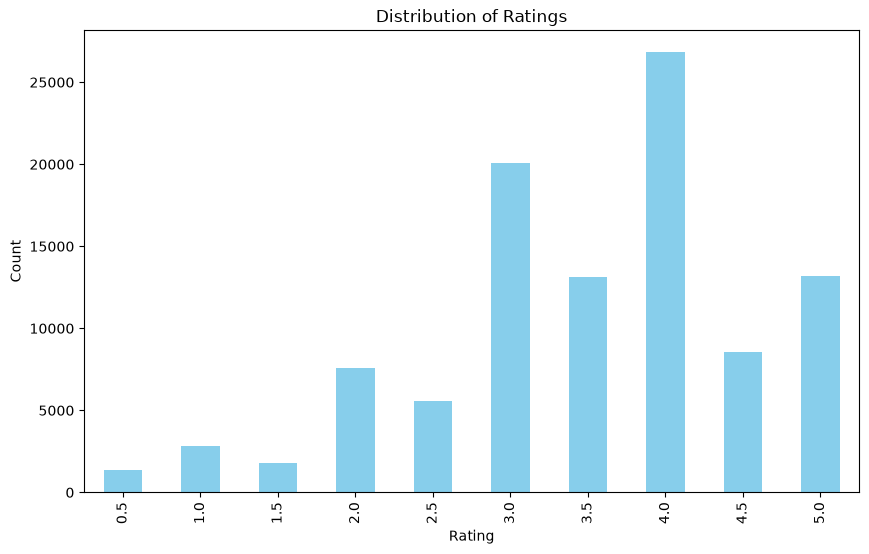

In [33]:
rating_counts.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Distribution of Ratings per User

We examine how many movies each user has rated.

In [34]:
ratings_per_user = ratings.groupby('userId').size()
display(ratings_per_user.describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

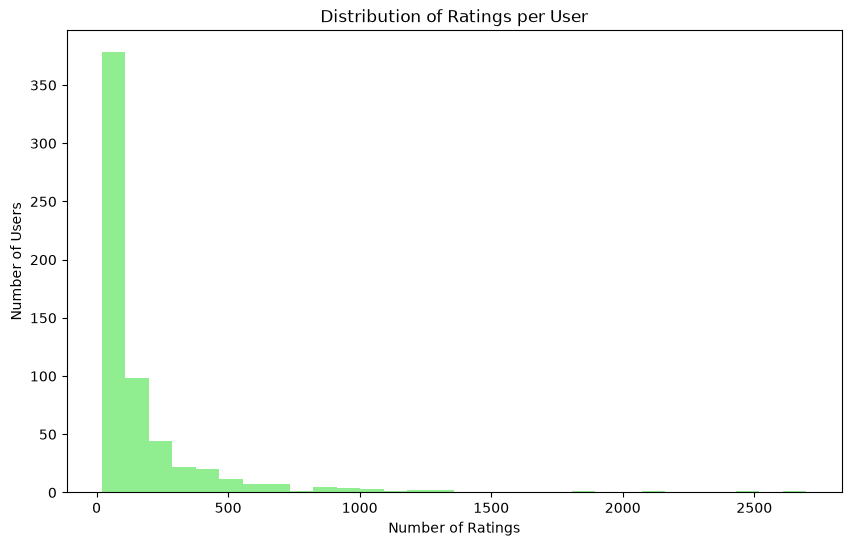

In [35]:
ratings_per_user.plot(kind='hist', bins=30, color='lightgreen', figsize=(10, 6))
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

### Observation

* The dataset contains 610 unique users, 9,724 unique movies, and 100,836 ratings.
* The user-item matrix is highly sparse, with approximately 98.30% of all possible user-movie pairs having no rating.
* The most frequent rating is 4.0, followed by 3.0. Ratings between 3.0 and 5.0 account for a substantial portion of the recorded ratings.
* The number of ratings per user varies considerably. The mean is approximately 165.30, while the median is 70.5, indicating that some users contribute substantially more ratings than others.
* These observations highlight the importance of handling missing ratings correctly and comparing users or movies based only on co-rated entries in the subsequent collaborative filtering implementation.


# Part B — Similarity metrics from scratch

### Getting Co-Rated Entries

This function extracts aligned rating vectors using only the entries rated by both users or assigned ratings by both items.
Missing ratings are excluded rather than treated as zero.

In [36]:
def get_co_rated(matrix,a,b,axis="index"):
    if axis=="index":
        vec1 = matrix.loc[a]
        vec2 = matrix.loc[b]
    elif axis=="columns":
        vec1 = matrix[a]
        vec2 = matrix[b]
    else:
        raise ValueError("Axis must be 'index' or 'columns'")
    # Find the indices where both vectors have non-NaN values
    co_rated = vec1.notna() & vec2.notna()
    return (vec1[co_rated].to_numpy(dtype=float), vec2[co_rated].to_numpy(dtype=float))    

In [37]:
example_matrix = pd.DataFrame(
    {
        101: [5.0, 4.0, np.nan],
        102: [3.0, np.nan, 2.0],
        103: [4.0, 5.0, 3.0]
    },
    index=[1, 2, 3]
)

user_a, user_b = get_co_rated(example_matrix, 1, 2, axis="index")

print("User 1 co-rated values:", user_a)
print("User 2 co-rated values:", user_b)

User 1 co-rated values: [5. 4.]
User 2 co-rated values: [4. 5.]


In [38]:
movie_a, movie_b = get_co_rated( example_matrix, 101, 102, axis="columns")

print("Movie 101 co-rated values:", movie_a)
print("Movie 102 co-rated values:", movie_b)

Movie 101 co-rated values: [5.]
Movie 102 co-rated values: [3.]


### Euclidean Similarity

Euclidean distance measures the magnitude of the differences between co-rated values.
We convert the distance into a similarity score using 1 / (1 + distance), so smaller distances correspond to higher similarities.

In [65]:
def euclidean_distance(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=float)
    vec2 = np.asarray(vec2, dtype=float)

    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be of the same length")
    if len(vec1) < 2:
        raise ValueError("Vectors must have at least two elements to compute Euclidean distance")
    d = np.sqrt(np.sum((vec1 - vec2) ** 2))
    sim = 1 / (1 + d)
    return sim
    

### Cosine Similarity

Calculate cosine similarity between two aligned rating vectors.
Returns None if fewer than two co-rated values are available or if either vector has zero magnitude.

In [40]:
def cosine_similarity(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=float)
    vec2 = np.asarray(vec2, dtype=float)

    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be of the same length")
    if len(vec1) < 2:
        raise ValueError("Vectors must have at least two elements to compute cosine similarity")
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    
    sim = dot_product / (norm_vec1 * norm_vec2)
    return sim

### Pearson Correlation
Calculate Pearson correlation between two aligned rating vectors.

Returns None if fewer than two co-rated values are available or if either centered vector has zero magnitude.

In [41]:
def pearson_similarity(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=float)
    vec2 = np.asarray(vec2, dtype=float)

    if len(vec1) != len(vec2):
        raise ValueError("Vectors must be of the same length")
    if len(vec1) < 2:
        raise ValueError("Vectors must have at least two elements to compute Pearson similarity")
    
    mean_vec1 = np.mean(vec1)
    mean_vec2 = np.mean(vec2)
    
    numerator = np.sum((vec1 - mean_vec1) * (vec2 - mean_vec2))
    denominator = np.sqrt(np.sum((vec1 - mean_vec1) ** 2)) * np.sqrt(np.sum((vec2 - mean_vec2) ** 2))
    
    if denominator == 0:
        return None    
    sim = numerator / denominator
    return sim

### Sanity Checks

We test the similarity functions using the example provided in the assignment.
The Euclidean distance should be 4, the cosine similarity should be approximately 0.987, and the Pearson correlation should be 1.0.

In [42]:
A = np.array([5,4,5,3], dtype=float)
B = np.array([3,2,3,1], dtype=float)

# euclidean distance and similarity status

euclidean_distance = np.sqrt(np.sum((A-B)**2))
euclidean_similarity = 1 / (1 + euclidean_distance)

# cosine similarity
cosine_sim = cosine_similarity(A, B)

# pearson similarity
pearson_sim = pearson_similarity(A, B)

print(f"Euclidean Distance: {euclidean_distance:.4f}, Euclidean Similarity: {euclidean_similarity:.4f}")
print(f"Cosine Similarity: {cosine_sim:.4f}")
print(f"Pearson Similarity: {pearson_sim:.4f}")


Euclidean Distance: 4.0000, Euclidean Similarity: 0.2000
Cosine Similarity: 0.9872
Pearson Similarity: 1.0000


# Part C — User-based collaborative filtering
In this part, we identify users with similar rating patterns and use their ratings to predict missing ratings for a target user.

### Finding the K Nearest Users

For a target user, we calculate similarities with all other users using only co-rated movies.
Users with fewer than two co-rated movies or undefined similarity values are skipped.
The remaining users are sorted in descending order of similarity.

In [43]:
def find_k_nearest_users(matrix, target_user, k ,similarity_fn):

    if target_user not in matrix.index:
        raise ValueError(f"Target user {target_user} not found in the matrix.")

    if k <= 0:
        raise ValueError("k must be a positive integer.")

    similarities = []

    target_ratings = matrix.loc[target_user]

    for user in matrix.index:
        if user == target_user:
                continue
        co_rated_target, co_rated_user = get_co_rated(matrix, target_user, user, axis="index")
        
        if len(co_rated_target) < 2:
                continue
        
        sim = similarity_fn(co_rated_target, co_rated_user)
        
        if sim is None or not np.isfinite(sim):
                continue
        similarities.append((user, sim))

    # Sort the list of similarities in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Return the k nearest users
    return similarities[:k]

In [44]:
# testing
toy_matrix = pd.DataFrame(
    {
        101: [5.0, 5.0, 1.0, 4.0],
        102: [4.0, 4.0, 2.0, 3.0],
        103: [3.0, 3.0, 5.0, np.nan],
        104: [2.0, np.nan, 4.0, np.nan]
    },
    index=[1, 2, 3, 4]
)

nearest_users = find_k_nearest_users(
    toy_matrix,
    target_user=1,
    k=2,
    similarity_fn=pearson_similarity
)

for user_id, similarity in nearest_users:
    print(f"User {user_id}: similarity = {similarity:.3f}")

User 2: similarity = 1.000
User 4: similarity = 1.000


### User-Based Rating Prediction

The predicted rating is calculated as a similarity-weighted average of the ratings given by the target user's nearest neighbors.
Only neighbors who rated the target movie are included. If no usable neighbors are available, the function returns None.

In [45]:
def predict_rating_user_based(matrix, target_user, target_movie, k, similarity_fn):
    if target_user not in matrix.index:
        raise ValueError(f"Target user {target_user} not found in the matrix.")
    if target_movie not in matrix.columns:
        raise ValueError(f"Target movie {target_movie} not found in the matrix.")
    if k <= 0:
        raise ValueError("k must be a positive integer.")

    nearest_users = find_k_nearest_users(matrix, target_user, k, similarity_fn)

    numerator = 0.0
    denominator = 0.0

    for neighbor_id, similarity in nearest_users:
        # use the neighbor's rating for the target movie
        neighbor_rating = matrix.loc[neighbor_id, target_movie]
        
        if pd.notna(neighbor_rating):
            # weight the neighbor's rating by the similarity
            numerator += similarity * neighbor_rating
            denominator += abs(similarity)

    if denominator == 0:
        return None

    predicted_rating = numerator / denominator
    return predicted_rating

In [46]:
# test 
toy_matrix = pd.DataFrame(
    {
        101: [5.0, 5.0, 1.0, 4.0],
        102: [4.0, 4.0, 2.0, 3.0],
        103: [3.0, 3.0, 5.0, np.nan],
        104: [2.0, np.nan, 4.0, np.nan],
        105: [np.nan, 5.0, 1.0, 4.0]
    },
    index=[1, 2, 3, 4]
)

prediction = predict_rating_user_based(
    toy_matrix,
    target_user=1,
    target_movie=105,
    k=3,
    similarity_fn=pearson_similarity
)

print("Predicted rating:", prediction)

Predicted rating: 2.861643441566333


# Part D — Item-based collaborative filtering
Find nearest items and predict ratings

In [47]:
#find_k_nearest_items
def find_k_nearest_items(matrix, target_item, k, similarity_fn):

    if target_item not in matrix.columns:
        raise ValueError(f"Target item {target_item} not found in the matrix.")

    if k <= 0:
        raise ValueError("k must be a positive integer.")

    similarities = []

    for item in matrix.columns:
        if item == target_item:
            continue

        co_rated_target, co_rated_item = get_co_rated(
            matrix,
            target_item,
            item,
            axis="columns"
        )

        if len(co_rated_target) < 2:
            continue

        sim = similarity_fn(co_rated_target, co_rated_item)

        if sim is None or not np.isfinite(sim):
            continue

        similarities.append((item, sim))

    # Sort the list of similarities in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Return the k nearest items
    return similarities[:k]

In [48]:
#testing
toy_matrix = pd.DataFrame(
    {
        101: [5.0, 5.0, 1.0, 4.0],
        102: [4.0, 4.0, 2.0, 3.0],
        103: [3.0, 3.0, 5.0, np.nan],
        104: [2.0, np.nan, 4.0, np.nan]
    },
    index=[1, 2, 3, 4]
)

nearest_items = find_k_nearest_items(
    toy_matrix,
    target_item=101,
    k=2,
    similarity_fn=pearson_similarity
)

for item_id, similarity in nearest_items:
    print(f"Item {item_id}: similarity = {similarity:.3f}")

Item 102: similarity = 0.966
Item 104: similarity = -1.000


In [49]:
#predict_rating_item_based
def predict_rating_item_based(matrix, target_user, target_item, k, similarity_fn):

    if target_user not in matrix.index:
        raise ValueError(f"Target user {target_user} not found in the matrix.")

    if target_item not in matrix.columns:
        raise ValueError(f"Target item {target_item} not found in the matrix.")

    if k <= 0:
        raise ValueError("k must be a positive integer.")

    nearest_items = find_k_nearest_items(
        matrix,
        target_item,
        k,
        similarity_fn
    )

    numerator = 0.0
    denominator = 0.0

    for neighbor_item, similarity in nearest_items:

        # use the target user's rating for the similar item
        user_rating = matrix.loc[target_user, neighbor_item]

        if pd.notna(user_rating):
            # weight the rating by the similarity
            numerator += similarity * user_rating
            denominator += abs(similarity)

    if denominator == 0:
        return None

    predicted_rating = numerator / denominator

    return predicted_rating

In [50]:
#testing
toy_matrix = pd.DataFrame(
    {
        101: [5.0, 5.0, 1.0, 4.0],
        102: [4.0, 4.0, 2.0, 3.0],
        103: [3.0, 3.0, 5.0, np.nan],
        104: [2.0, np.nan, 4.0, np.nan],
        105: [np.nan, 5.0, 1.0, 4.0]
    },
    index=[1, 2, 3, 4]
)

prediction = predict_rating_item_based(
    toy_matrix,
    target_user=1,
    target_item=105,
    k=3,
    similarity_fn=pearson_similarity
)

print("Predicted rating:", prediction)

Predicted rating: 1.9734993995195198


### Part D — 12. Reuse from Part C

The item-based functions reuse the same similarity functions and weighted-average prediction logic from Part C. The main change is that neighbors are computed over items (columns) instead of users (rows).

# Part E — Evaluation

Evaluate the collaborative filtering models using a user-based and item-based approach with different similarity measures and values of k.

### 13. Train-Test Split

In [51]:
def train_test_split_ratings(ratings_df, test_fraction=0.2):
    train_parts = []
    test_parts = []

    for user_id, user_ratings in ratings_df.groupby('userId'):
        n_test = int(len(user_ratings) * test_fraction)

        test_sample = user_ratings.sample(n=n_test, random_state=42)
        train_sample = user_ratings.drop(test_sample.index)

        train_parts.append(train_sample)
        test_parts.append(test_sample)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, test_df

In [52]:
# Test
train_df, test_df = train_test_split_ratings(ratings)

print("Training ratings:", len(train_df))
print("Testing ratings:", len(test_df))
print("Total ratings:", len(train_df) + len(test_df))

Training ratings: 80896
Testing ratings: 19940
Total ratings: 100836


In [53]:
# Check the split for one user
user_id = 1

print("User 1 total ratings:", len(ratings[ratings['userId'] == user_id]))
print("User 1 training ratings:", len(train_df[train_df['userId'] == user_id]))
print("User 1 testing ratings:", len(test_df[test_df['userId'] == user_id]))

User 1 total ratings: 232
User 1 training ratings: 186
User 1 testing ratings: 46


### 14. Evaluation

Evaluate the predictions using RMSE and MAE, and report the fraction of test cases for which a prediction was not possible.

In [59]:
def evaluate(matrix, test_df, k, similarity_fn, method):
    predictions = []
    actuals = []
    impossible = 0

    for _, row in test_df.iterrows():
        user_id = row['userId']
        movie_id = row['movieId']
        true_rating = row['rating']

        try:
            if method == "user-based":
                prediction = predict_rating_user_based(
                    matrix, user_id, movie_id, k, similarity_fn
                )

            elif method == "item-based":
                prediction = predict_rating_item_based(
                    matrix, user_id, movie_id, k, similarity_fn
                )

            else:
                raise ValueError("method must be 'user-based' or 'item-based'")

        except ValueError:
            prediction = None

        if prediction is None:
            impossible += 1
        else:
            predictions.append(prediction)
            actuals.append(true_rating)

    if len(predictions) == 0:
        return None, None, impossible / len(test_df)

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))

    impossible_fraction = impossible / len(test_df)

    return rmse, mae, impossible_fraction

  

In [67]:
rmse, mae, impossible_fraction = evaluate(
    train_matrix,
    test_df.head(100),
    k=5,
    similarity_fn=cosine_similarity,
    method="user-based"
)

print("RMSE:", rmse)
print("MAE:", mae)
print("Impossible fraction:", impossible_fraction)

RMSE: 1.6668413698882656
MAE: 1.0681752929809567
Impossible fraction: 0.89


### 15. Full Grid Evaluation

Run all combinations of user-based and item-based collaborative filtering with Euclidean, Cosine, and Pearson similarity measures for k = 5, 10, 20, and 50.

In [87]:
similarity_functions = {
    "euclidean": euclidean_sim_e,
    "cosine": cosine_sim_e,
    "pearson": pearson_sim_e
}

methods = ["user-based", "item-based"]
k_values = [5, 10, 20, 50]

print("Total experiments:", len(methods) * len(similarity_functions) * len(k_values))

Total experiments: 24
